# Thai Datasets — EDA
**Thai Food Recommendation Engine (Group: Flower)**

The Thai side of the project. Companion to `eda_rir_data.ipynb` (the English RIRD baseline).

| Dataset | Path | Role |
|---|---|---|
| **Wongnai** | `datasets/wongnai/` | Thai review corpus (the real Thai input demo) |
| **Thailand Foods** | `datasets/thailand_foods.csv` | Dish gazetteer (ingredients, region, course) |
| **M-ABSA (Thai)** | `datasets/m-absa/*/th/` | Thai aspect-based sentiment signal |

**Product goal (unchanged):** a user types a **Thai** taste preference and gets ranked
recommendations with justifying review sentences. See the conclusion for how each
dataset supports (or limits) that.

> Run with the **cpdsai** venv kernel.


In [ ]:
import re
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

HERE = Path.cwd()
ROOT = HERE if (HERE / "datasets").exists() else HERE.parent
DATA = ROOT / "datasets"

# Thai fonts are usually absent from matplotlib; keep Thai text out of plot labels.
pd.set_option("display.width", 140); pd.set_option("display.ma" \
"x_columns", 40)

THAI = re.compile(r"[\u0e00-\u0e7f]"); LATIN = re.compile(r"[A-Za-z]")
def script_of(t):
    if not isinstance(t, str) or not t.strip(): return "empty"
    th, la = bool(THAI.search(t)), bool(LATIN.search(t))
    if th and la: return "mixed"
    if th: return "thai"
    if la: return "latin"
    return "other"
print("data dir:", DATA)

data dir: /Users/samichirungta/Desktop/computer_programming/reccomender_project/Food_Recommendation_Engine/datasets


## 1. Wongnai reviews
Source: HuggingFace `Highgroundbkk/wongnai_reviews`, exported to parquet.
Only two columns: `review_body` (Thai) and `star_rating`.

In [2]:
wg_tr = pd.read_parquet(DATA / "wongnai" / "train.parquet")
wg_te = pd.read_parquet(DATA / "wongnai" / "test.parquet")
print("train:", wg_tr.shape, "| test:", wg_te.shape)
print("columns:", list(wg_tr.columns), "| nulls:", wg_tr.isna().sum().to_dict())
wg_tr.head(3)

train: (40000, 2) | test: (6203, 2)
columns: ['review_body', 'star_rating'] | nulls: {'review_body': 0, 'star_rating': 0}


,review_body,star_rating
0,ร้านอาหารใหญ่มากกกกกกก \nเลี้ยวเข้ามาเจอห้องน้...,2
1,อาหารที่นี่เป็นอาหารจีนแคะที่หากินยากในบ้านเรา...,3
2,ปอเปี๊ยะสด ทุกวันนี้รู้สึกว่าหากินยาก (ร้านที่...,2


### 1a. Rating distribution — note the scale is **0–4**, not 1–5

star_rating
0      415
1     1845
2    12171
3    18770
4     6799
Name: count, dtype: int64


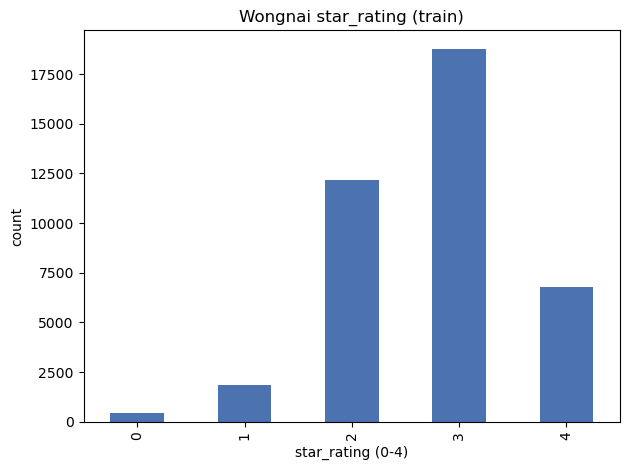

In [3]:
vc = wg_tr["star_rating"].value_counts().sort_index()
print(vc)
vc.plot(kind="bar", color="#4C72B0", title="Wongnai star_rating (train)")
plt.xlabel("star_rating (0-4)"); plt.ylabel("count"); plt.tight_layout(); plt.show()

### 1b. Review length
Median ~20 words — far shorter than RIRD's ~94. Sentence splitting still helps on the long tail.

count    40000.000000
mean        30.482975
std         33.008267
min          1.000000
25%         13.000000
50%         20.000000
75%         35.000000
max       1002.000000
Name: words, dtype: float64


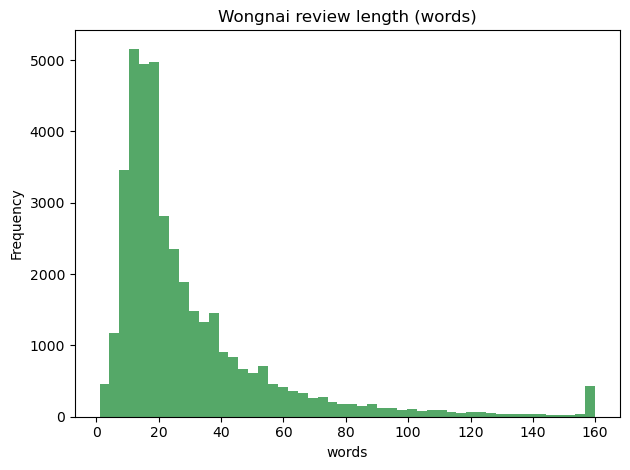

In [4]:
wg_tr["words"] = wg_tr["review_body"].str.split().map(len)
print(wg_tr["words"].describe())
wg_tr["words"].clip(upper=wg_tr["words"].quantile(0.99)).plot(
    kind="hist", bins=50, color="#55A868", title="Wongnai review length (words)")
plt.xlabel("words"); plt.tight_layout(); plt.show()

### 1c. Language check

In [5]:
sc = wg_tr["review_body"].sample(5000, random_state=0).map(script_of)
print((sc.value_counts(normalize=True) * 100).round(2))
print("\nexample (Thai):")
print(" ", wg_tr["review_body"].iloc[0][:160].replace(chr(10), " "))

review_body
thai     63.74
mixed    35.78
latin     0.48
Name: proportion, dtype: float64

example (Thai):
  ร้านอาหารใหญ่มากกกกกกก  เลี้ยวเข้ามาเจอห้องน้ำก่อนเลย เออแปลกดี  ห้องทานหลักๆอยู่ชั้น 2 มีกาแฟ น้ำผึ้ง ซึ่งก็แค่เอาน้ำผึ้งมาราด แพงเวอร์ อย่าสั่งเลย  ลาบไข่ต้ม 


> **Structural limitation:** Wongnai has **no restaurant id, no query, no relevance label** —
> only review text + rating. It is a Thai *text* corpus, not a labelled
> reviewed-item-retrieval benchmark like RIRD.

## 2. Thailand Foods (dish gazetteer)
A reference table of Thai dishes — not reviews. Useful for normalizing / expanding
food terms in queries and reviews.

In [6]:
foods = pd.read_csv(DATA / "thailand_foods.csv")
print("shape:", foods.shape, "| cols:", list(foods.columns))
print("nulls:", foods.isna().sum().to_dict())
dups = foods.duplicated(subset=["en_name"]).sum()
print("duplicate en_name:", dups)
foods.head(3)

shape: (325, 6) | cols: ['en_name', 'th_name', 'ingredients', 'course', 'province', 'region']
nulls: {'en_name': 0, 'th_name': 0, 'ingredients': 0, 'course': 0, 'province': 0, 'region': 0}
duplicate en_name: 3


,en_name,th_name,ingredients,course,province,region
0,Koi,ก้อย,Beef+lime juice+fish sauce+chili+herbs,main dish,Ubon Ratchathani,Northeast
1,Kuai Chap,กวยจั๊บ,Pork belly+rice noodles+soy sauce+garlic,main dish,Bangkok,Central
2,Kuai Tiao,ก๋วยเตี๋ยว,Rice noodles+pork+bean sprouts+garlic+fish sauce,main dish,Bangkok,Central


### 2a. Dedupe + category breakdown

after dedupe: 322 dishes

course:
 course
main dish    173
snack         78
dessert       68
salad          2
soup           1

region (note heavy Various/Unknown):
 region
Various      144
Unknown      100
Central       42
South         15
North         12
Northeast      9


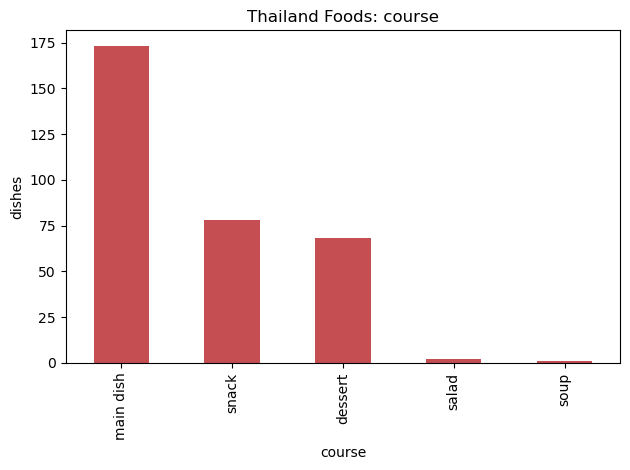

In [7]:
foods_clean = foods.drop_duplicates(subset=["en_name"]).reset_index(drop=True)
print("after dedupe:", foods_clean.shape[0], "dishes")
print("\ncourse:\n", foods_clean["course"].value_counts().to_string())
print("\nregion (note heavy Various/Unknown):\n", foods_clean["region"].value_counts().to_string())
foods_clean["course"].value_counts().plot(
    kind="bar", color="#C44E52", title="Thailand Foods: course")
plt.ylabel("dishes"); plt.tight_layout(); plt.show()

### 2b. Ingredient vocabulary
Ingredients are `+`-separated; this gives a rough flavour/ingredient lexicon.

In [8]:
ing = (foods_clean["ingredients"].dropna().str.split("+").explode().str.strip().str.lower())
print("distinct ingredient tokens:", ing.nunique())
print("\ntop 15:\n", ing.value_counts().head(15).to_string())

distinct ingredient tokens: 149

top 15:
 ingredients
unknown         98
herbs           64
sugar           61
coconut milk    54
garlic          51
flour           38
meat            29
rice flour      27
soy sauce       27
fish sauce      25
pork            25
vegetables      25
spices          21
chicken         10
chili           10


## 3. M-ABSA (Thai) — aspect-based sentiment
Format per line: `sentence####[[target, aspect_category, polarity], ...]`.
Food-relevant domains: `restaurant` and `food`.

In [9]:
def load_mabsa(domain):
    rows = []
    for split in ["train", "dev", "test"]:
        p = DATA / "m-absa" / domain / "th" / f"{split}.txt"
        for line in p.read_text(encoding="utf-8").splitlines():
            if "####" not in line: continue
            sent, tuples = line.split("####", 1)
            try:
                tup = eval(tuples)
            except Exception:
                tup = []
            rows.append({"domain": domain, "split": split, "sentence": sent, "tuples": tup})
    return pd.DataFrame(rows)

mabsa = pd.concat([load_mabsa("restaurant"), load_mabsa("food")], ignore_index=True)
print("rows:", len(mabsa))
print(mabsa.groupby(["domain", "split"]).size())

rows: 4236
domain      split
food        dev       312
            test      522
            train    1278
restaurant  dev       316
            test      544
            train    1264
dtype: int64


### 3a. Aspect categories & polarity
These are coarse ABSA labels — **not** flavour axes (sour/spicy/cheap).

aspect categories:
 tuples
food quality                1789
food general                1041
service general              580
restaurant general           497
ambience general             354
food style_options           337
food prices                  169
restaurant miscellaneous     115
restaurant prices             95
food recommendation           86
drinks quality                68
amazon availability           65
drinks style_options          46
shipment quality              46
location general              39
shipment delivery             38
amazon prices                 33
drinks prices                 23
shipment prices                5

polarity:
 tuples
positive    3914
negative    1227
neutral      283
conflict       2


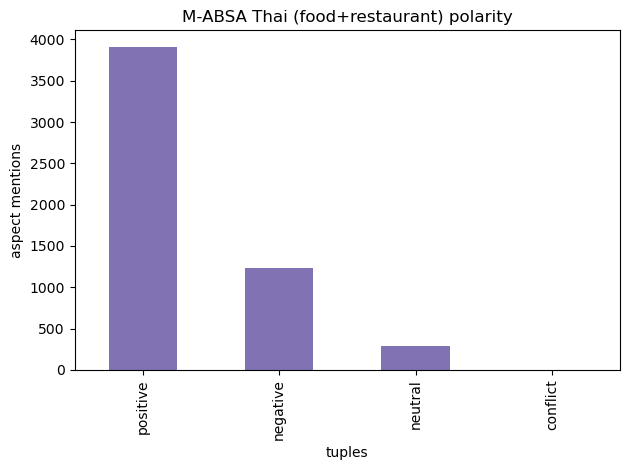

In [10]:
exploded = mabsa.explode("tuples").dropna(subset=["tuples"])
exploded = exploded[exploded["tuples"].map(lambda x: isinstance(x, (list, tuple)) and len(x) == 3)]
cat = exploded["tuples"].map(lambda x: x[1])
pol = exploded["tuples"].map(lambda x: x[2])
print("aspect categories:\n", cat.value_counts().to_string())
print("\npolarity:\n", pol.value_counts().to_string())
pol.value_counts().plot(kind="bar", color="#8172B3", title="M-ABSA Thai (food+restaurant) polarity")
plt.ylabel("aspect mentions"); plt.tight_layout(); plt.show()

## 4. Conclusion — does "user types Thai → gets recommendation" still hold?

**Yes, that is still the product goal.** What the data dictates is *how* we get there:

| Need | Dataset | Status |
|---|---|---|
| Method development + **evaluation** (restaurant grouping + relevance labels) | **RIRD (English)** | ✅ has `business_id` + `PMD.csv` labels |
| **Thai** review text for the live demo | **Wongnai** | ✅ 46k Thai reviews — but **no restaurant id / query / label** |
| Food term normalization / expansion | **Thailand Foods** | ✅ ~320 dishes (after dedupe) |
| Thai aspect-sentiment signal | **M-ABSA Thai** | ✅ coarse ABSA, not flavour axes |

**Plan:**
1. Build & measure the fusion/ranking method on **RIRD** (English, labelled).
2. Demo in **Thai** on **Wongnai** — at the **review/sentence level** (Thai query →
   most relevant Thai review sentences), because Wongnai lacks restaurant grouping.
3. For true Thai *restaurant* recommendation, either obtain Wongnai metadata with
   restaurant ids, or translate RIRD queries to Thai for a restaurant-level demo.

So the Thai-input experience is real; only the *restaurant-level evaluation* stays on
RIRD until richer Thai metadata exists.
